In [2]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
np.set_printoptions(precision=2)   # Reduced display precision on numpy arrays

In [3]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [4]:
# Matrix X contains examples
# Each row of the matrix represents one example
# When you have m training examples and there are n features, X is a matrix with dimensions
# (m, n)
# m rows, n columns

# date is stored in numpy array/matrix
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


In [7]:
# w is a vector with n elements
# Each element contains the parameter associated with one feature
# In our dataset, n is 4
# notionally, we draw this as a column vector

# b is a scalar parameter

# For demonstration,  𝐰  and  𝑏  will be loaded with some initial selected values
# that are near the optimal.  𝐰  is a 1-D NumPy vector.
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


In [10]:
''' Model Prediction With Multiple Variables:

The models prediction with multiple variables is given by the linear model
where . is a vector dot product

Single Prediction element by element:

Our previous prediction multiplied one feature value by one parameter and added a
bias parameter. A direct extension of our previous implementation of prediction to
multiple features would be to implement the multiple variable linear model formula
using a loop over each element, performing the multiply with its parameter and then 
adding the bias parameter at the end. '''

def predict_single_loop(x, w, b):
    ''' Single predict using linear regression'''
    n = x.shape[0]
    p = 0
    for i in range(n):
        p_i = x[i] * w[i]
        p = p + p_i
    p = p + b
    return p

In [12]:
# Get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# Make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


In [14]:
''' Single Prediction, vector:

Noting that the multiple linear model equation can be implemented using the dot product.
We can make use of the vector operations to speed up predictions.

Recall from the Numpy lab that Numpy np.dot() can be used to perform a vector dot product.
'''

def predict(x, w, b):
    p = np.dot(x, w) + b
    return p

In [15]:
# Get a row from out training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# Make a prediction
f_wb = predict(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

# Going forward np.dot will be used for these operations.

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


In [18]:
# Compute Cost with multiple variables:

def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost = cost + (f_wb_i - y[i]) ** 2
    cost = cost / (2 * m)
    return cost

In [19]:
# Compute and display cost using our prechosen optimal parameters
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f"Cost at optimal w: {cost}")

Cost at optimal w: 1.5578904045996674e-12


In [20]:
# Compute Gradient Descent with multiple variables:

def compute_gradient(X, y, w, b):

    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i, j]
        dj_db = dj_db + err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw


In [21]:
# Compute and display gradient
tmp_dj_db, tmp_dj_dw = compute_gradient(X_train, y_train, w_init, b_init)
print(f"dj_db at initial w,b: {tmp_dj_db}")
print(f"dj_dw at initial w,b: {tmp_dj_dw}")

dj_db at initial w,b: -1.6739251122999121e-06
dj_dw at initial w,b: [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05]


In [24]:

def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    # Performs batch gradient descent to learn w and b.
    # Updates w and b by num_iter gradient steps with learning rate alpha

    # An array to store cost J and w's at each iteration
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w, b)

        # Update parameters using w, b, alpha and gradient
        w = w -  alpha * dj_dw
        b = b - alpha * dj_db

        # Save cost J at each iteration
        if i < 100000:
            J_history.append( cost_function(X, y, w, b))

        # Print cost every at intervals 10 times or as many iterations if i < 10
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Itration {i:4d}: Cost {J_history[-1]:8.2f}    ")

    return w, b, J_history
        
        

In [26]:
# Initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.

# Some gradient descent settings
iterations = 1000
alpha = 5.0e-7

# Run gradient descent
w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b,
                                           compute_cost, compute_gradient, alpha,
                                           iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final}  ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Itration    0: Cost  2529.46    
Itration  100: Cost   695.99    
Itration  200: Cost   694.92    
Itration  300: Cost   693.86    
Itration  400: Cost   692.81    
Itration  500: Cost   691.77    
Itration  600: Cost   690.73    
Itration  700: Cost   689.71    
Itration  800: Cost   688.70    
Itration  900: Cost   687.69    
b,w found by gradient descent: -0.00,[ 0.2   0.   -0.01 -0.07]  
prediction: 426.19, target value: 460
prediction: 286.17, target value: 232
prediction: 171.47, target value: 178


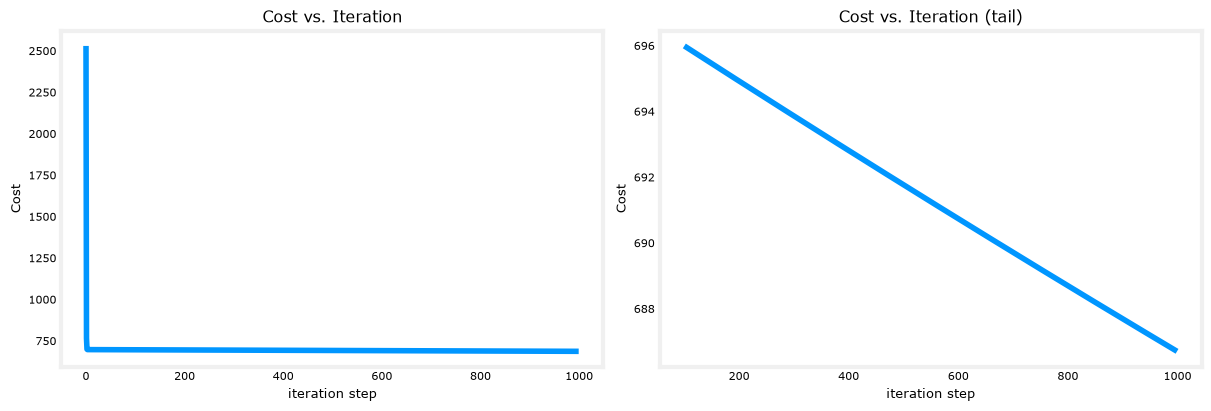

In [27]:
# Plot cost versus iteration

fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. Iteration"); ax2.set_title("Cost vs. Iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

In [28]:
# Cost is still declining and our predictions are not very accurate.
# The next lab will explore how to improve this!